In [1]:
from read_data import load_subject, interp_data
import sys
sys.path.insert(1, '../plotter')
from plotter import plot_timeseries, plot_activity

In [2]:
df = load_subject('101')

Total structured columns generated: 54
First 10 columns: ['timestamp', 'activity_id', 'heart_rate', 'hand_temp', 'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z', 'hand_acc6_x', 'hand_acc6_y', 'hand_acc6_z']
Reading from ../PAMAP2_Dataset/Protocol/subject101.dat
Loading raw subject file (this might take a few seconds because it is a massive telemetry file)...

--- RAW DATA DIAGNOSTICS FOR SUBJECT 101 ---
Total raw rows: 376,417
Total continuous tracking time: 62.88 minutes

Top 5 Columns with the Highest Percentage of Missing Data (NaNs):
heart_rate      90.864121
hand_temp        0.386274
hand_acc16_x     0.386274
hand_acc16_y     0.386274
hand_acc6_x      0.386274
dtype: float64


Row 313792 has NaN values for the hand gyroscope measurements:

In [3]:
df.loc[313792,['hand_gyro_x','hand_gyro_y','hand_gyro_z']]

hand_gyro_x   NaN
hand_gyro_y   NaN
hand_gyro_z   NaN
Name: 313792, dtype: float64

We can use interp_data to generate a new dataframe with interpolated NaN values when the sequence of NaNs is smaller than the given window (default 3 seconds):

In [4]:
df_interp = interp_data(df,t_window=3,columns=['hand_gyro_x','hand_gyro_y','hand_gyro_z'])
df_interp.loc[313792,['hand_gyro_x','hand_gyro_y','hand_gyro_z']]

Column hand_gyro_x has 0.39% NaNs.
Interpolating in hand_gyro_x...
Column hand_gyro_x now has 0.0% NaNs!

Column hand_gyro_y has 0.39% NaNs.
Interpolating in hand_gyro_y...
Column hand_gyro_y now has 0.0% NaNs!

Column hand_gyro_z has 0.39% NaNs.
Interpolating in hand_gyro_z...
Column hand_gyro_z now has 0.0% NaNs!



hand_gyro_x    2.568855
hand_gyro_y   -1.616395
hand_gyro_z   -1.468155
Name: 313792, dtype: float64

Row 313792 was part of a short enough sequence, so there are now interpolated values in the dataframe. We can see the effect by plotting the segment with 313792 before the interpolation:

Using input dataframe!


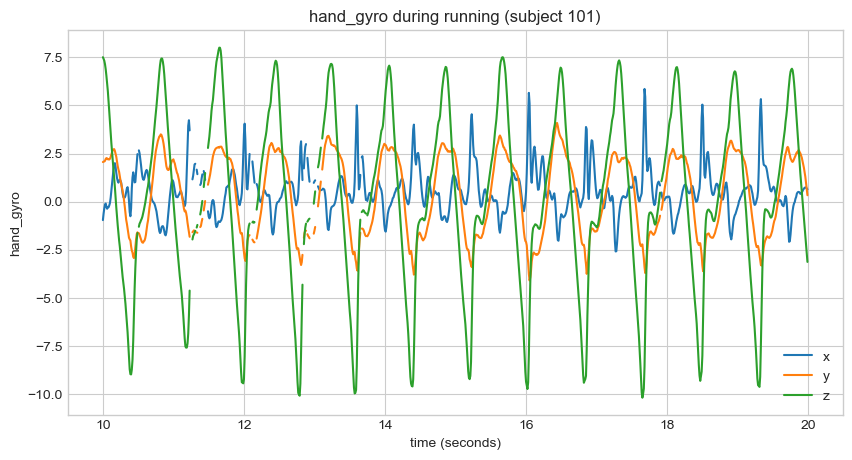

In [5]:
seg1 = plot_activity('101', 'running', sensor='hand_gyro',df=df)

and after the interpolation:

Using input dataframe!


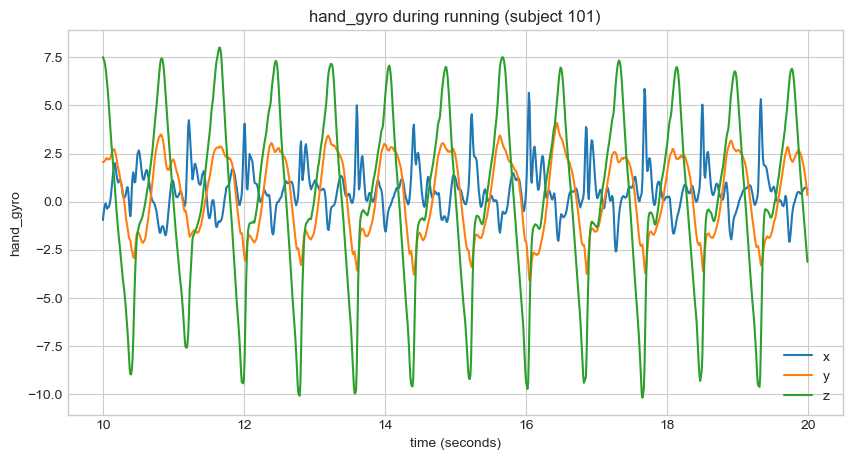

In [6]:
seg2 = plot_activity('101', 'running', sensor='hand_gyro',df=df_interp)

Here is a dataframe with the default columns interpolated (all except heart rate, timestamp, and activity ID):

In [7]:
df_interp_all = interp_data(df,t_window=3)

Column hand_temp has 0.39% NaNs.
Interpolating in hand_temp...
Column hand_temp now has 0.0% NaNs!

Column hand_acc16_x has 0.39% NaNs.
Interpolating in hand_acc16_x...
Column hand_acc16_x now has 0.0% NaNs!

Column hand_acc16_y has 0.39% NaNs.
Interpolating in hand_acc16_y...
Column hand_acc16_y now has 0.0% NaNs!

Column hand_acc16_z has 0.39% NaNs.
Interpolating in hand_acc16_z...
Column hand_acc16_z now has 0.0% NaNs!

Column hand_acc6_x has 0.39% NaNs.
Interpolating in hand_acc6_x...
Column hand_acc6_x now has 0.0% NaNs!

Column hand_acc6_y has 0.39% NaNs.
Interpolating in hand_acc6_y...
Column hand_acc6_y now has 0.0% NaNs!

Column hand_acc6_z has 0.39% NaNs.
Interpolating in hand_acc6_z...
Column hand_acc6_z now has 0.0% NaNs!

Column hand_gyro_x has 0.39% NaNs.
Interpolating in hand_gyro_x...
Column hand_gyro_x now has 0.0% NaNs!

Column hand_gyro_y has 0.39% NaNs.
Interpolating in hand_gyro_y...
Column hand_gyro_y now has 0.0% NaNs!

Column hand_gyro_z has 0.39% NaNs.
Interpol

Here is an example with a much smaller window, so we can see that some NaNs remain:

In [8]:
df_interp_all = interp_data(df,t_window=0.01)

Column hand_temp has 0.39% NaNs.
Interpolating in hand_temp...
Column hand_temp now has 0.13% NaNs!

Column hand_acc16_x has 0.39% NaNs.
Interpolating in hand_acc16_x...
Column hand_acc16_x now has 0.13% NaNs!

Column hand_acc16_y has 0.39% NaNs.
Interpolating in hand_acc16_y...
Column hand_acc16_y now has 0.13% NaNs!

Column hand_acc16_z has 0.39% NaNs.
Interpolating in hand_acc16_z...
Column hand_acc16_z now has 0.13% NaNs!

Column hand_acc6_x has 0.39% NaNs.
Interpolating in hand_acc6_x...
Column hand_acc6_x now has 0.13% NaNs!

Column hand_acc6_y has 0.39% NaNs.
Interpolating in hand_acc6_y...
Column hand_acc6_y now has 0.13% NaNs!

Column hand_acc6_z has 0.39% NaNs.
Interpolating in hand_acc6_z...
Column hand_acc6_z now has 0.13% NaNs!

Column hand_gyro_x has 0.39% NaNs.
Interpolating in hand_gyro_x...
Column hand_gyro_x now has 0.13% NaNs!

Column hand_gyro_y has 0.39% NaNs.
Interpolating in hand_gyro_y...
Column hand_gyro_y now has 0.13% NaNs!

Column hand_gyro_z has 0.39% NaNs.